Celsius values: [-40. -10.   0.   8.  15.  22.  38.]
Fahrenheit values: [-40.   14.   32.   46.4  59.   71.6 100.4]

Starting model training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model training finished.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Prediction for 100 Celsius: 211.59 Fahrenheit
Actual value for 100 Celsius: 212.00 Fahrenheit


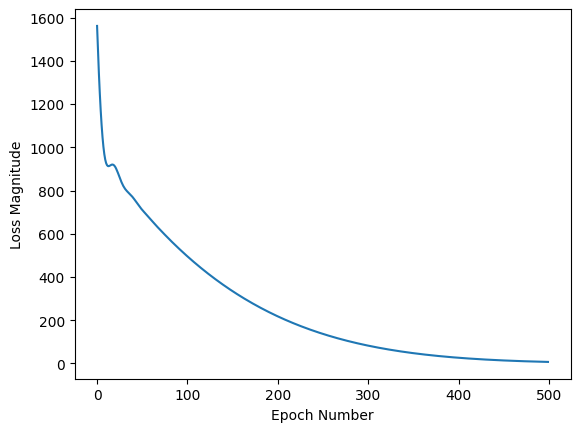

In [1]:
import tensorflow as tf
import numpy as np

# 1. Prepare data
# Generate some Celsius values
celsius_q = np.array([-40, -10, 0, 8, 15, 22, 38], dtype=float)
# Corresponding Fahrenheit values (F = C * 1.8 + 32)
fahrenheit_a = celsius_q * 1.8 + 32

print("Celsius values:", celsius_q)
print("Fahrenheit values:", fahrenheit_a)

# 2. Define the model architecture
# A simple Sequential model with one Dense layer
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, input_shape=[1])
])

# 3. Compile the model
# Use Adam optimizer and Mean Squared Error as the loss function
model.compile(loss='mean_squared_error',
              optimizer=tf.keras.optimizers.Adam(0.1))

# 4. Train the model
print("\nStarting model training...")
history = model.fit(celsius_q, fahrenheit_a, epochs=500, verbose=0)
print("Model training finished.")

# 5. Evaluate/Predict
# Let's see how well the model predicts new values
# The model expects a 2D array for input, even for a single prediction (e.g., [[100.0]])
predicted_fahrenheit = model.predict(np.array([[100.0]]))[0][0]
print(f"\nPrediction for 100 Celsius: {predicted_fahrenheit:.2f} Fahrenheit")

# Compare with actual value
actual_fahrenheit = 100 * 1.8 + 32
print(f"Actual value for 100 Celsius: {actual_fahrenheit:.2f} Fahrenheit")

# You can also visualize the training loss
import matplotlib.pyplot as plt

plt.xlabel('Epoch Number')
plt.ylabel("Loss Magnitude")
plt.plot(history.history['loss'])
plt.show()